In [14]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib as m
from tqdm import tqdm
from scipy import linalg
import scipy as sp
import os
import pickle
import glob
import h5py
import random

from scipy.constants import *

phi0 = physical_constants["mag. flux quantum"][0]
eps0 = epsilon_0

from scipy.special import eval_hermite
import scfitpy.qfitter as Qfit

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
# Configure matplotlib 
plt.rcParams["font.size"] = 18
plt.rcParams["mathtext.fontset"] = "stix"

os.chdir(".\outs")

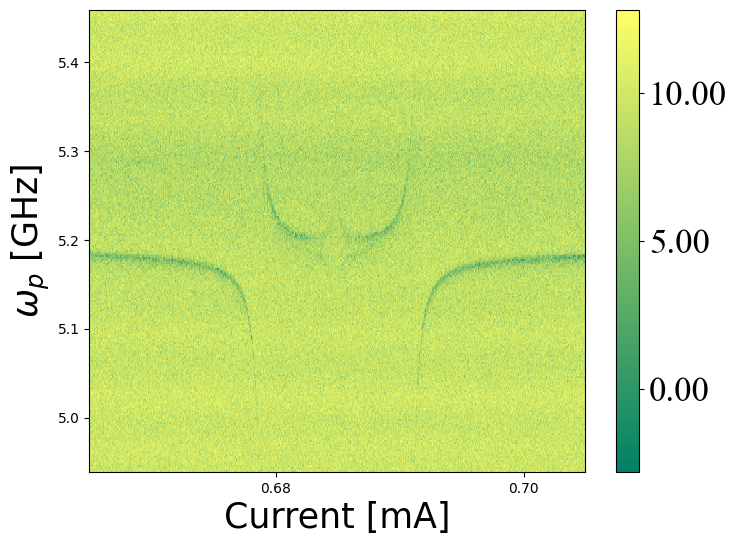

In [2]:
# Load test spectrum
_dat = np.load("./assets/cwSpec_currentSweep_202407011423.npz")
current = _dat["current"]  # mA
freq = _dat["freq"]  # GHz

mag1 = _dat["mag1"]  # 2d-spectrum date, dims=[freq, current]

fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams["font.size"] = 25
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

X, Y = np.meshgrid(freq, current)
mappable = ax.pcolor(Y, X, mag1, cmap="summer")
cbar_num_format = "%.2f"
cbar = plt.colorbar(mappable, ax=ax, format=cbar_num_format)

plt.xlabel(r"Current [mA]", fontsize=25)
plt.ylabel(r"$\omega_p\ $[GHz]", fontsize=25)
plt.show()

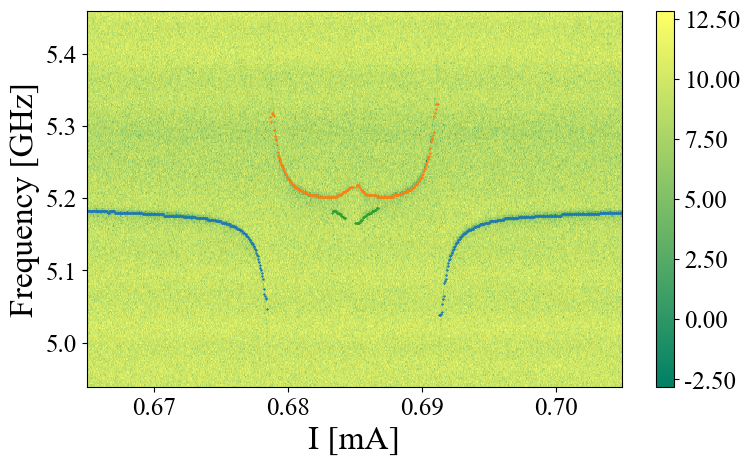

In [11]:
f = open("peak_dict.pkl", "rb")
peak_dict = pickle.load(f)

#### from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(8, 5))

X, Y = np.meshgrid(freq, current)
mappable = ax.pcolor(Y, X, mag1, cmap="summer")
cbar_num_format = "%.2f"
cbar = plt.colorbar(mappable, ax=ax, format=cbar_num_format)

ax.plot(peak_dict['a'][:,0], peak_dict['a'][:,1], "*", ms=1, label='a')
ax.plot(peak_dict['b'][:,0], peak_dict['b'][:,1], "*", ms=1, label='b')
ax.plot(peak_dict['c'][:,0], peak_dict['c'][:,1], "*", ms=1, label='c')

ax.set_ylabel("Frequency [GHz]", fontsize=24)
ax.set_xlabel(r"I [mA]", fontsize=24)
fig.tight_layout()
plt.show()

In [12]:
init_params = (3.5, 1.2, 5.18, 0.1e-3, 0.1e-3, 760, 6.8495e-01)

In [20]:
current1 = np.linspace(np.min(current), np.max(current), 101) - init_params[6]
E1Q = Qfit.Rabi(current1, init_params)

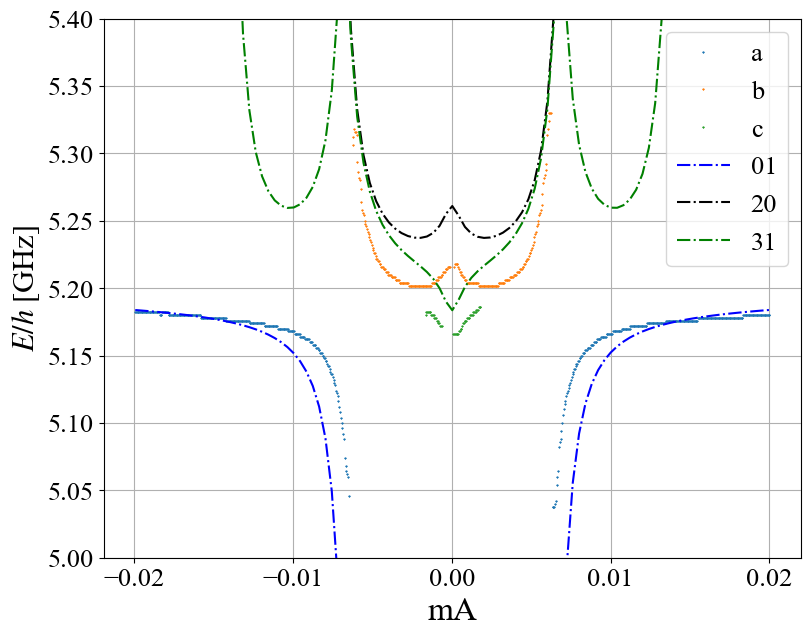

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(peak_dict['a'][:,0]- init_params[6], peak_dict['a'][:,1], "*", ms=1, label='a')
ax.plot(peak_dict['b'][:,0]- init_params[6], peak_dict['b'][:,1], "*", ms=1, label='b')
ax.plot(peak_dict['c'][:,0]- init_params[6], peak_dict['c'][:,1], "*", ms=1, label='c')

ax.plot(current1, np.array(E1Q[1]) - np.array(E1Q[0]), "-.", color="b", label="01")
ax.plot(current1, np.array(E1Q[2]) - np.array(E1Q[0]), "-.", color="black", label="20")
ax.plot(current1, np.array(E1Q[3]) - np.array(E1Q[1]), "-.", color="g", label="31")

ax.set_ylim([5, 5.4])
plt.grid()
plt.xlabel(r"mA", fontsize=24)
plt.ylabel(r"$E/h\ $[GHz]", fontsize=22)
plt.legend(loc="upper right", ncol=1)
plt.show()

In [25]:
def err(params):
    Ef = [[] for i in range(3)]

    Ef[0] = Qfit.Rabi(peak_dict['a'][:,0] - params[6], params)
    Ef[1] = Qfit.Rabi(peak_dict['b'][:,0] - params[6], params)
    Ef[2] = Qfit.Rabi(peak_dict['c'][:,0] - params[6], params)

    ere1 = abs(peak_dict['a'][:,1] - np.array(Ef[0][1]) + np.array(Ef[0][0]))
    ere2 = abs(peak_dict['b'][:,1] - np.array(Ef[1][2]) + np.array(Ef[1][0]))
    ere3 = abs(peak_dict['c'][:,1] - np.array(Ef[2][3]) + np.array(Ef[2][1]))
    err = 100 * [
        np.sum(ere1) / len(ere1),
        np.sum(ere2) / len(ere2),
        np.sum(ere3) / len(ere3),
        0,
        0,
        0,
        0,
    ]
    return err


Ere = err(init_params)
print(np.sum(Ere))

8.995787895712883


In [26]:
import time
from scipy.optimize import leastsq
start = time.time()

fitparams=leastsq(err,init_params)

elapsed_time = time.time() - start
print ("elapsed_time:{0}".format(elapsed_time/60) + "[min]")

with open('RabiFit.pickle', mode='wb') as fo:
    pickle.dump(fitparams[0], fo)

elapsed_time:5.316887895266215[min]


In [27]:
f = open("RabiFit.pickle", "rb")
fitparams0 = pickle.load(f)
print(fitparams0)
E1Q = Qfit.Rabi(current1, fitparams0)
print(np.sum(err(fitparams0)))

[3.43177221e+00 8.19673203e-01 5.17078197e+00 1.73787764e-04
 1.45924870e-04 8.17233313e+02 6.84928454e-01]
0.5774376791153282


In [28]:
# Ip calculation
f2 = 684.4 * 1e-3
f3 = -539.4 * 1e-3
df = f2 - f3
fitparams0[5] * df * h * 1e9 / phi0

np.float64(3.2047702455854266e-07)

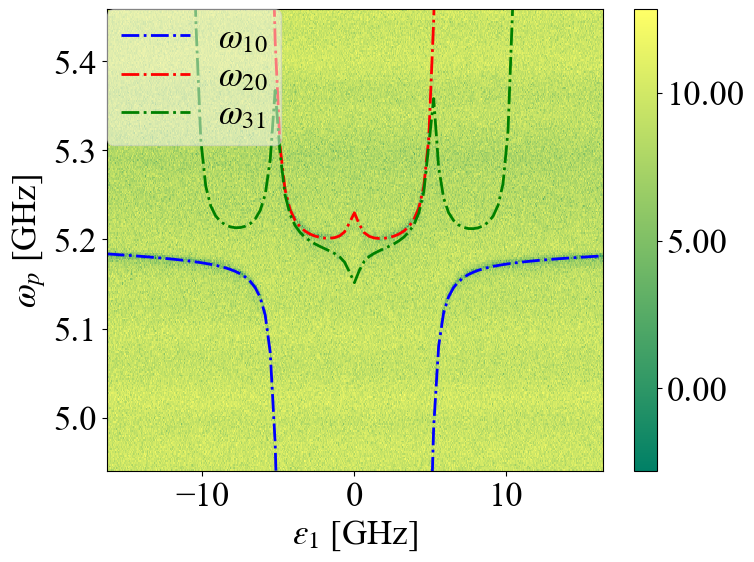

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

X, Y = np.meshgrid(freq, (current - fitparams0[6]) * fitparams0[5])
mappable = ax.pcolor(Y, X, mag1, cmap="summer")
cbar_num_format = "%.2f"
cbar = plt.colorbar(mappable, ax=ax, format=cbar_num_format)


ax.plot(
    current1 * fitparams0[5],
    np.array(E1Q[1]) - np.array(E1Q[0]),
    "-.",
    lw=2,
    color="b",
    label="$\\omega_{10}$",
)
ax.plot(
    current1 * fitparams0[5],
    np.array(E1Q[2]) - np.array(E1Q[0]),
    "-.",
    lw=2,
    color="r",
    label="$\\omega_{20}$",
)
ax.plot(
    current1 * fitparams0[5],
    np.array(E1Q[3]) - np.array(E1Q[1]),
    "-.",
    lw=2,
    color="g",
    label="$\\omega_{31}$",
)

ax.set_ylim([min(freq), max(freq)])
# plt.grid()
plt.xlabel(r"$\varepsilon_1$ [GHz]", fontsize=25)
plt.ylabel(r"$\omega_p\ $[GHz]", fontsize=25)
plt.legend(
    loc="upper left",
    borderaxespad=0,
    labelspacing=0.2,
    ncol=1,
    labelcolor="black",
    facecolor="whitesmoke",
    framealpha=0.5,
)
plt.savefig("RabiFit.png", bbox_inches="tight", pad_inches=0.5, dpi=700)
plt.show()